In [1]:
# function arguments in square brackets:
#   sigmoid[x] = 1/(Exp[-x] + 1)
#   fittedFunction[x] = (1 - sigmoid[k (x - xTransit)]) (m x + b) + sigmoid[k (x - xTransit)] (A - (x - x0)^2/w^2)

# fitted parameters for the two cases from the Chinese paper:
#   red solid line:
#   {k -> 9.23956, xTransit -> 6.01045, m -> 0.925636, b -> 1.06618, A -> 22.3591, x0 -> 5.00522, w -> 0.258814}
#   green solid line:
#   {k -> 9.49589, xTransit -> 5.90375, m -> 0.540344, b -> 1.87238, A -> 7.92089, x0 -> 5.59392, w -> 0.171838}
import numpy as np 
def electronSpectrum_g2dNdg_loglog(x, k, xTransit, m, b, A, x0, w):
    sigmoid = 1 / (np.exp(-k * (x - xTransit)) + 1)
    fittedFunction = (1 - sigmoid) * (m * x + b) + sigmoid * (A - ((x - x0) ** 2) / (w ** 2))
    return fittedFunction 

(0.0, 8.0)

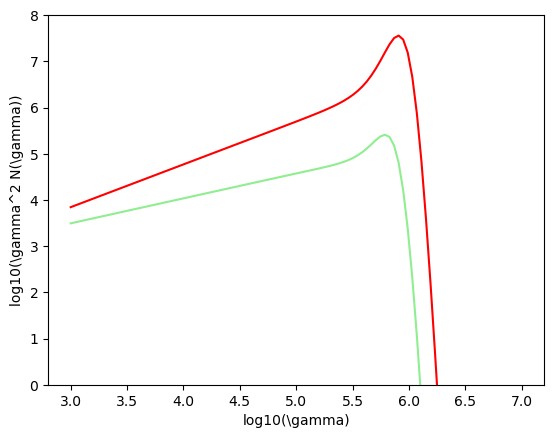

In [2]:
# draw the electron distribution

import matplotlib.pyplot as plt
x = np.linspace(3, 7, 100)
y1 = electronSpectrum_g2dNdg_loglog(x, 9.23956, 6.01045, 0.925636, 1.06618, 22.3591, 5.00522, 0.258814)
y2 = electronSpectrum_g2dNdg_loglog(x, 9.49589, 5.90375, 0.540344, 1.87238, 7.92089, 5.59392, 0.171838)
plt.plot(x, y1, label='red solid line', color='red')
plt.plot(x, y2, label='green solid line', color='lightgreen')
plt.xlabel('log10(\gamma)')
plt.ylabel('log10(\gamma^2 N(\gamma))') 
plt.ylim(0, 8)

In [3]:
def electronSpectrum_g2dNdg(x, k, xTransit, m, b, A, x0, w):
    X=np.log10(x)
    sigmoid = 1 / (np.exp(-k * (X - xTransit)) + 1)
    fittedFunction = (1 - sigmoid) * (m * X + b) + sigmoid * (A - ((X - x0) ** 2) / (w ** 2))
    return 10**fittedFunction 

(1, 100000000.0)

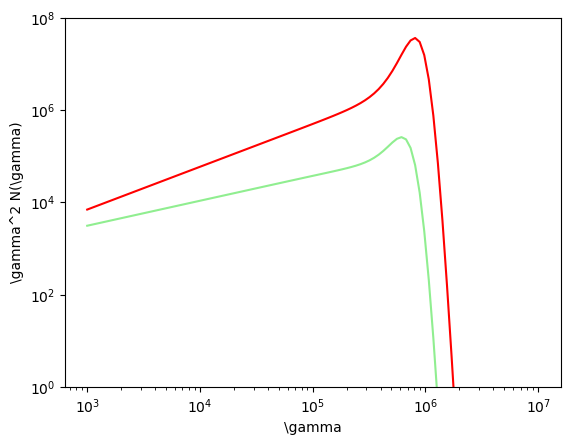

In [4]:

import matplotlib.pyplot as plt
x = np.logspace(3, 7, 100)
y1 = electronSpectrum_g2dNdg(x, 9.23956, 6.01045, 0.925636, 1.06618, 22.3591, 5.00522, 0.258814)
y2 = electronSpectrum_g2dNdg(x, 9.49589, 5.90375, 0.540344, 1.87238, 7.92089, 5.59392, 0.171838)
plt.plot(x, y1, label='red solid line', color='red')
plt.plot(x, y2, label='green solid line', color='lightgreen')
plt.xlabel('\gamma')
plt.ylabel('\gamma^2 N(\gamma)') 
plt.yscale('log')
plt.xscale('log')
plt.ylim(1, 1e8)

In [5]:
def electronSpectrum_g2dNdg_2(x, k, xTransit, m, b, A, x0, w):
    B= 10**b
    X=np.log10(x)
    sigmoid = 1 / (np.exp(-k * (X - xTransit)) + 1)
    fittedFunction = (1 - sigmoid) * (B*x**m) + sigmoid * (A - ((X - x0) ** 2) / (w ** 2))
    return 10**fittedFunction 

In [6]:
def electronSpectrum_dNdg(x, k, xTransit, m, b, A, x0, w):
    X=np.log10(x)
    sigmoid = 1 / (np.exp(-k * (X - xTransit)) + 1)
    fittedFunction = (1 - sigmoid) * (m * X + b) + sigmoid * (A - ((X - x0) ** 2) / (w ** 2))
    return 10**fittedFunction /x**2

In [7]:
10**5.59392

392572.61419082637

In [10]:
10**5

100000

(1e-10, 1.0)

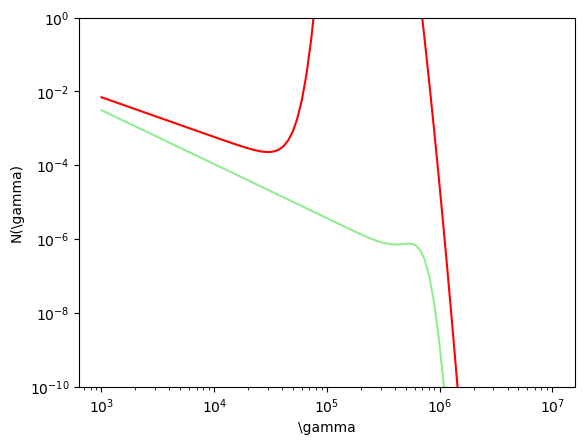

In [9]:

import matplotlib.pyplot as plt
x = np.logspace(3, 7, 100)
#                          gamma, k, gammaTransit, m, b, A, gammaPeak, w
# y1 = electronSpectrum_dNdg(x, 9.23956, 6.01045, 0.925636, 1.06618, 22.3591, 5.00522, 0.258814)
y1 = electronSpectrum_dNdg(x, 9.23956, 5, 0.925636, 1.06618, 22.3591, 5, 0.258814)
y2 = electronSpectrum_dNdg(x, 9.49589, 5.90375, 0.540344, 1.87238, 7.92089, 5.59392, 0.171838)
plt.plot(x, y1, label='red solid line', color='red')
plt.plot(x, y2, label='green solid line', color='lightgreen')
plt.xlabel('\gamma')
plt.ylabel('N(\gamma)') 
plt.yscale('log')
plt.xscale('log')
# plt.xlim(1,1e7)
plt.ylim(1e-10, 1e0)


In [11]:
def electronSpectrum_dNdg(gamma, amplitude, k, gammaTransit, m, b, A, gammaPeak, w):
    X=np.log10(gamma)
    X_0=np.log10(gammaPeak)
    sigmoid = 1 / (np.exp(-k * (X - gammaTransit)) + 1)
    fittedFunction = (1 - sigmoid) * (m * X + b) + sigmoid * (A - ((X - X_0) ** 2) / (w ** 2))
    return amplitude*10**fittedFunction /gamma**2

(1e-10, 1.0)

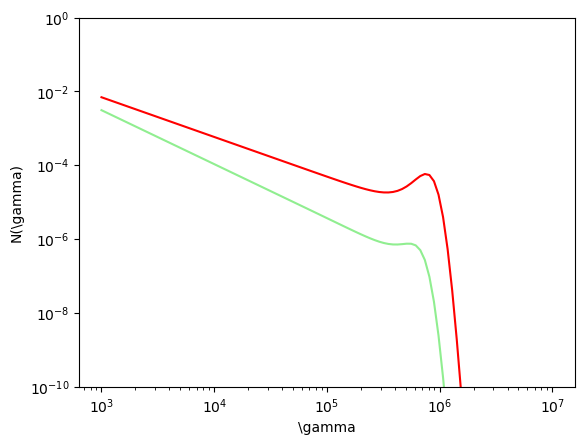

In [12]:

import matplotlib.pyplot as plt
x = np.logspace(3, 7, 100)
#                          gamma, k, gammaTransit, m, b, A, gammaPeak, w
y1 = electronSpectrum_dNdg(x, 1., 9.23956, 6.01045, 0.925636, 1.06618, 22.3591,101209.20185832502, 0.258814)
y2 = electronSpectrum_dNdg(x, 1., 9.49589, 5.90375, 0.540344, 1.87238, 7.92089,392572.61419082637, 0.171838)
plt.plot(x, y1, label='red solid line', color='red')
plt.plot(x, y2, label='green solid line', color='lightgreen')
plt.xlabel('\gamma')
plt.ylabel('N(\gamma)') 
plt.yscale('log')
plt.xscale('log')
# plt.xlim(1,1e7)
plt.ylim(1e-10, 1e0)


In [13]:
from jetset.jet_emitters import EmittersDistribution
n_e_pileup=EmittersDistribution('pileup',spectral_type='user_defined')
n_e_pileup.add_par('gammaTransit',par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('gammaPeak',  par_type='gamma_grid',val=50000.,vmin=1., vmax=None, unit='lorentz-factor')
n_e_pileup.add_par('amplitude',par_type='scaling_factor',val=1.0,vmin=0., vmax=1e30, unit='')
n_e_pileup.add_par('k',par_type='scaling_factor',val=10.0,vmin=0., vmax=100., unit='')
n_e_pileup.add_par('m',par_type='LE_spectral_slope',val=1.0,vmin=-10., vmax=10, unit='')
n_e_pileup.add_par('b',par_type='scaling_factor',val=10.0,vmin=0., vmax=100., unit='')
n_e_pileup.add_par('A',par_type='scaling_factor',val=10.0,vmin=0., vmax=100., unit='')
n_e_pileup.add_par('w',par_type='spectral_curvature',val=6.0,vmin=0., vmax=100., unit='')
n_e_pileup.set_distr_func(electronSpectrum_dNdg)

/Users/kazuma/anaconda3/envs/jetset/lib/python3.9/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


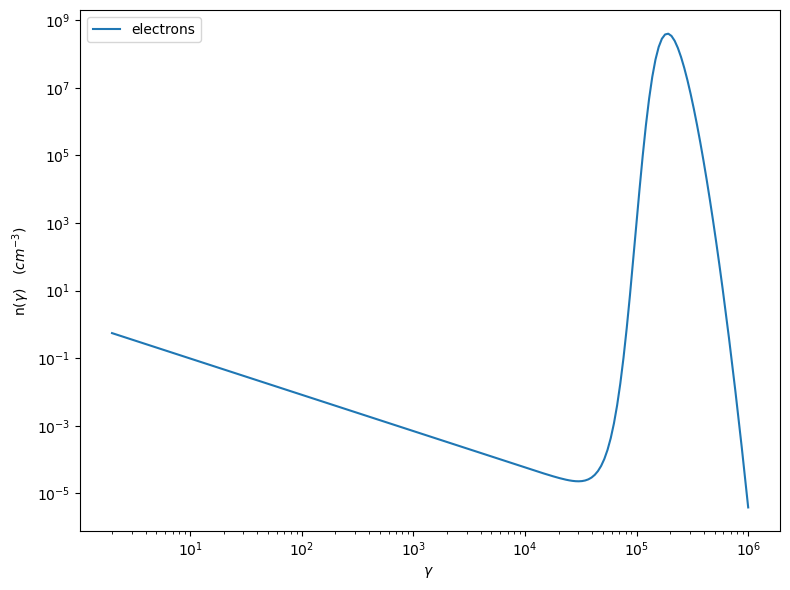

In [21]:
n_e_pileup.parameters.gammaPeak.val  =101209.20185832502
# n_e_pileup.parameters.gammaPeak.val  =10**5
n_e_pileup.parameters.k.val =9.23956
# n_e_pileup.parameters.gammaTransit.val =5.8
n_e_pileup.parameters.gammaTransit.val =5.0
# n_e_pileup.parameters.gammaTransit.val =6.01045
n_e_pileup.parameters.m.val =0.925636
n_e_pileup.parameters.b.val =1.06618
n_e_pileup.parameters.A.val =22.3591
n_e_pileup.parameters.w.val =0.258814 
n_e_pileup.parameters.amplitude.val =0.001
p=n_e_pileup.plot()
# p=n_e_pileup.plot(energy_unit='eV')

In [22]:
from jetset.jet_model import Jet
jet_pileup = Jet(emitters_distribution=n_e_pileup, verbose=False)
jet_pileup.set_par('z_cosm',0.034)
jet_pileup.set_par('R',8.8e15)  # Taken from Table 7.
jet_pileup.set_par('R_H',1.0e17)  # Guessing value
jet_pileup.set_par('N',0.54)  # Taken from Table 7.
jet_pileup.set_par('gmin',1.0e3)  # Guessing value
jet_pileup.set_par('gmax',1.0e7)  # Taken from Table 7.
jet_pileup.show_model()

jet_pileup.eval()



--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  

electrons distribution:
 type: pileup  
 gamma energy grid size:  201
 gmin grid : 2.000000e+00
 gmax grid : 1.000000e+06
 normalization:  False
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e-01

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sync, state: self-abs
   name:SSC, state: on
external fields transformation method: blob

SED info:
 nu grid size jetkernel: 1000
 nu size: 500
 nu mix (Hz): 1.000000e+06
 nu max (Hz): 1.000000e+30

flux plot lower bound   :  1.000000e-30

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,8.800000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,lorentz-factor*,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.400000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+07,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,5.400000e-01,0.000000e+00,--,False,False
jet_leptonic,gammaTransit,gamma_grid,lorentz-factor*,5.000000e+00,1.000000e+00,--,False,False


--------------------------------------------------------------------------------



--------------------------------------------------------------------------------
model description: 
--------------------------------------------------------------------------------
type: Jet
name: jet_leptonic  

electrons distribution:
 type: pileup  
 gamma energy grid size:  201
 gmin grid : 1.000000e+03
 gmax grid : 1.000000e+07
 normalization:  False
 log-values:  False
 ratio of cold protons to relativistic electrons: 1.000000e-01

radiative fields:
 seed photons grid size:  100
 IC emission grid size:  100
 source emissivity lower bound :  1.000000e-120
 spectral components:
   name:Sum, state: on
   name:Sync, state: self-abs
   name:SSC, state: on
external fields transformation method: blob

SED info:
 nu grid size jetkernel: 1000
 nu size: 500
 nu mix (Hz): 1.000000e+06
 nu max (Hz): 1.000000e+30

flux plot lower bound   :  1.000000e-30

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,8.800000e+15,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,lorentz-factor*,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.400000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+03,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+07,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,5.400000e-01,0.000000e+00,--,False,False
jet_leptonic,gammaTransit,gamma_grid,lorentz-factor*,5.000000e+00,1.000000e+00,--,False,False


--------------------------------------------------------------------------------


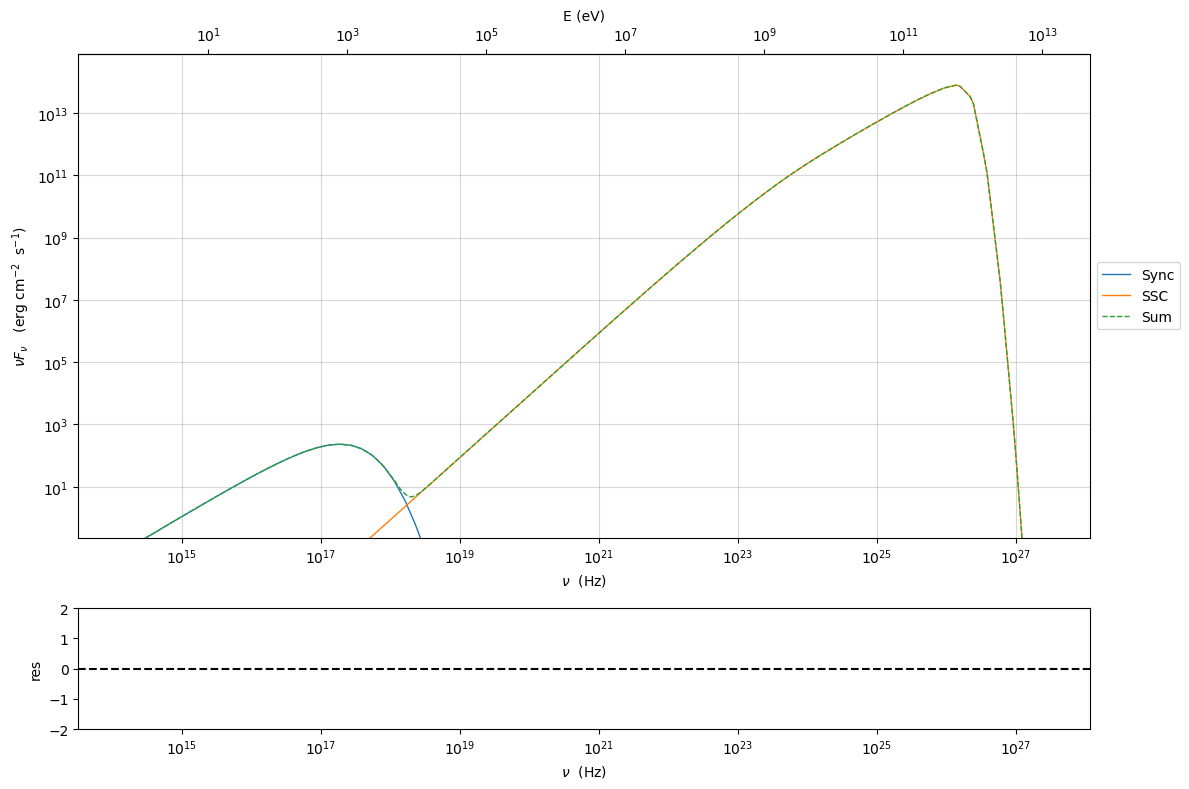

In [16]:
jet_pileup.show_model()
jet_pileup.set_gamma_grid_size(400)

p=jet_pileup.plot_model()